In [7]:
!pip install torch torchvision torchaudio nltk numpy pandas tqdm matplotlib fastparquet huggingface_hub datasets tabulate

  Using cached tabulate-0.9.0-py3-none-any.whl.metadata (34 kB)
Using cached tabulate-0.9.0-py3-none-any.whl (35 kB)


In [1]:
import sys
import os

# Path to the folder you want to add
subfolder_path = os.path.join(os.getcwd(), "n_gram_nn")

# Add it to sys.path
if subfolder_path not in sys.path:
    sys.path.append(subfolder_path)

In [2]:
import torch

import torch.nn as nn
import torch.optim as optim
import pandas as pd
from tabulate import tabulate

from n_gram_nn.dataset import prepare_dataset_loaders, calculate_max_context_window
from n_gram_nn.model import SentenceModel
from n_gram_nn.train import *
from n_gram_nn.seeding import enforce_reproducibility
from n_gram_nn.visualisation import *
from n_gram_nn.tuning import calculate_possible_windows

from n_gram_nn_results.result_handling import best_configuration

result_folder = "n_gram_nn_results"

device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
    info_logger("CUDA detected")

/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/xk84vl/Documents/Repos/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package punkt to /Users/xk84vl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt to /Users/xk84vl/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [3]:
### KEYS
REPLACE_FREQ_KEY = "replace_type"
TOP_FRACTION_KEY = "top_fraction"
EMBEDDING_DIM_KEY = "embedding_dim"
HIDDEN_DIM_KEY = "hidden_dim"
CONTEXT_WINDOW_KEY = "context_window_norm"
REPLACE_FRAC_KEY = "replace_frac"
LOSS_KEY = "loss"

In [8]:
# COMPARE RESULTS FROM FINETUNING ACROSS LANGUAGES TO FIND THE BEST COMBINATION
result_files = {
    "ko": "ko_tuning_results.csv",
    "ar": "ar_tuning_results.csv",
    "te": "te_tuning_results.csv"
}

best_configs, language_dfs = best_configuration(result_files, result_folder)

# # Sort by mean_loss
best_configs = best_configs.sort_values("mean_loss").head(5)

# Print best result per language
for language_df in language_dfs:
    best_row = language_df.nsmallest(1, LOSS_KEY).iloc[0]
    lang = best_row['language']
    loss = best_row[LOSS_KEY]
    print(f"The best loss for {lang} was {loss:.4f}")
print()

# Print the best results
print("=== Top 5 Cross-Language Configurations ===")
print(tabulate(best_configs, headers='keys', tablefmt='fancy_grid', showindex=False))

best_config = best_configs.head(1).iloc[0]  # This gives a Series instead of a dict

embed_dim = best_config[EMBEDDING_DIM_KEY]
hidden_dim = best_config[HIDDEN_DIM_KEY]
top_frac = best_config[TOP_FRACTION_KEY]
replace_type = best_config[REPLACE_FREQ_KEY]
replace_fraction = best_config[REPLACE_FRAC_KEY]
context_window_norm = best_config[CONTEXT_WINDOW_KEY]
batch_size = 16
epochs = 20

The best loss for ko was 3.5872
The best loss for ar was 4.4389
The best loss for te was 3.8597

=== Top 5 Cross-Language Configurations ===
╒════════════════╤════════════════╤═════════════════╤══════════════╤═══════════════════════╤════════════════╤═════════╤═════════╤═════════╤═════════════╤════════════╕
│ replace_type   │   top_fraction │   embedding_dim │   hidden_dim │ context_window_norm   │   replace_frac │      ar │      ko │      te │   mean_loss │   std_loss │
╞════════════════╪════════════════╪═════════════════╪══════════════╪═══════════════════════╪════════════════╪═════════╪═════════╪═════════╪═════════════╪════════════╡
│ False          │            0.1 │             256 │          256 │ max                   │           0.05 │ 4.60108 │ 3.58721 │ 3.85973 │     4.01601 │   0.524689 │
├────────────────┼────────────────┼─────────────────┼──────────────┼───────────────────────┼────────────────┼─────────┼─────────┼─────────┼─────────────┼────────────┤
│ False          │      

In [9]:
def get_context_window(language):
    context_window = calculate_max_context_window(language)
    if context_window_norm == "min":
        context_windows = calculate_possible_windows(context_window)
        context_window = min(window for window in context_windows if window > 1)
    return context_window

5
[2025-10-23 09:43:26,217] - [INFO] - Train dataset contains 2183 samples
[2025-10-23 09:43:26,217] - [INFO] - Validation dataset contains 239 samples
[2025-10-23 09:43:26,217] - [INFO] - Test dataset contains 356 samples
[2025-10-23 09:43:26,219] - [INFO] - Top 10.00% frequent words (410) out of 4109 total words
[2025-10-23 09:43:26,219] - [INFO] - The fragment to replace is 1.5740243902439024 of the 410 frequent words (410 out of 12907)
[2025-10-23 09:43:26,230] - [INFO] - Replaced 410 / 12907 tokens (3.18%)
[2025-10-23 09:43:26,339] - [INFO] - Replaced 13 / 1397 tokens (0.93%)
[2025-10-23 09:43:26,342] - [INFO] - Replaced 28 / 2088 tokens (1.34%)
[2025-10-23 09:43:26,343] - [INFO] - ==== Example Sentence ====
[2025-10-23 09:43:26,343] - [INFO] - Original:  30년 전쟁의 승자는 누구인가?
[2025-10-23 09:43:26,344] - [INFO] - Tokenized: ['30년', '전쟁의', '승자는', '누구인가', '?']
[2025-10-23 09:43:26,344] - [INFO] - Replaced:  ['30년', '전쟁의', '<UNK', '누구인가', '?']
[2025-10-23 09:43:26,346] - [INFO] - Window:

Epoch 1/20: 100%|██████████| 807/807 [00:03<00:00, 229.13it/s]

[2025-10-23 09:43:30,415] - [INFO] - Eval Loss: 5.0552 | Perplexity: 156.84 | Accuracy: 23.69% | Top-5 Accuracy: 55.26%



Epoch 2/20: 100%|██████████| 807/807 [00:03<00:00, 253.67it/s]

[2025-10-23 09:43:33,647] - [INFO] - Eval Loss: 4.5410 | Perplexity: 93.79 | Accuracy: 30.21% | Top-5 Accuracy: 56.62%


...

[2025-10-23 09:44:28,468] - [INFO] - Eval Loss: 3.5195 | Perplexity: 33.77 | Accuracy: 38.08% | Top-5 Accuracy: 64.35%



Epoch 19/20: 100%|██████████| 807/807 [00:03<00:00, 207.40it/s]

[2025-10-23 09:44:32,410] - [INFO] - Eval Loss: 3.5206 | Perplexity: 33.81 | Accuracy: 37.80% | Top-5 Accuracy: 64.71%



Epoch 20/20: 100%|██████████| 807/807 [00:03<00:00, 221.69it/s]


[2025-10-23 09:44:36,105] - [INFO] - Eval Loss: 3.5210 | Perplexity: 33.82 | Accuracy: 37.94% | Top-5 Accuracy: 64.71%


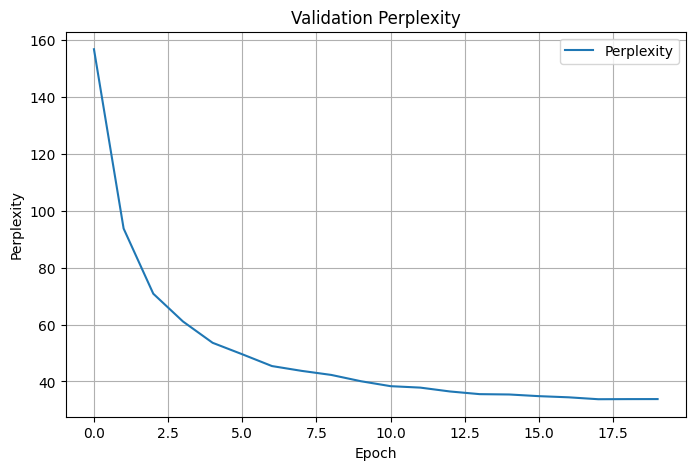

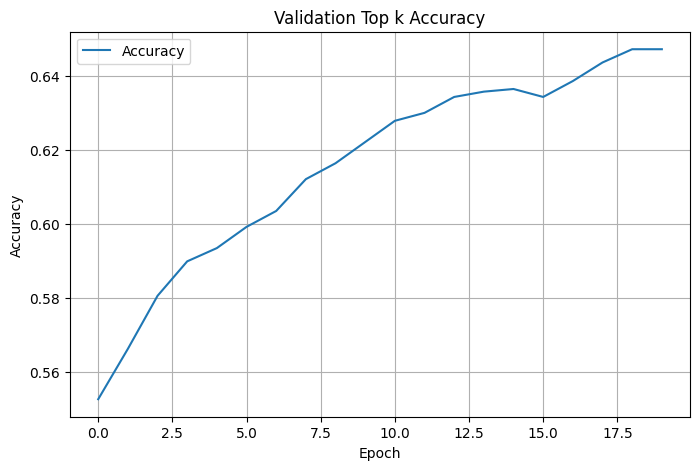

[2025-10-23 09:44:36,662] - [INFO] - Eval Loss: 3.5928 | Perplexity: 36.34 | Accuracy: 37.21% | Top-5 Accuracy: 62.55%


(3.5928242279651976,
 36.33655548095703,
 0.37212643678160917,
 0.6254789272030651)

In [10]:
enforce_reproducibility(42)

language = "ko"
model_name = f"model_{language}.model"
context_window = get_context_window(language)

train_loader, val_loader, test_loader, vocab = prepare_dataset_loaders(language, top_frac, replace_type, batch_size, replace_fraction, context_window)

model = SentenceModel(len(vocab), embed_dim, hidden_dim, context_window).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.NLLLoss()

val_losses, val_accs, val_pp, val_topk = train(model, device, train_loader, val_loader, optimizer, criterion, epochs)

plot_two_curves(val_losses, val_accs, save_path=f"{result_folder}/losses_{language}.pdf")
plot_one_curve(val_pp, "Validation Perplexity", "Perplexity")
plot_one_curve(val_topk, "Validation Top k Accuracy", "Accuracy")

torch.save(model.state_dict(), f"{result_folder}/{model_name}")

evaluate(model, device, test_loader, criterion, 5)

In [ ]:
enforce_reproducibility(42)

language = "ar"
model_name = f"model_{language}.pdf"
tuning_results = f"{language}_tuning_results.csv"
tuning_df = pd.read_csv(f"{result_folder}/{tuning_results}")
best_model_config = tuning_df.loc[tuning_df["loss"].idxmin()]
print(best_model_config)

embed_dim = best_model_config[EMBEDDING_DIM_KEY]
hidden_dim = best_model_config[HIDDEN_DIM_KEY]
top_frac = best_model_config[TOP_FRACTION_KEY]
replace_type = best_model_config[REPLACE_FREQ_KEY]
replace_fraction = best_model_config[REPLACE_FRAC_KEY]
context_window = best_model_config[CONTEXT_WINDOW_KEY]
batch_size = 16
epochs = 20

train_loader, val_loader, test_loader, vocab = prepare_dataset_loaders(language, top_frac, replace_type, batch_size, replace_fraction, context_window)

model = SentenceModel(len(vocab), embed_dim, hidden_dim, context_window).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.NLLLoss()

val_losses, val_accs, val_pp, val_topk = train(model, device, train_loader, val_loader, optimizer, criterion, epochs)

plot_two_curves(val_losses, val_accs, save_path=f"{result_folder}/losses_{language}.pdf")
plot_one_curve(val_pp, "Validation Perplexity", "Perplexity")
plot_one_curve(val_topk, "Validation Top k Accuracy", "Accuracy")

torch.save(model.state_dict(), f"{result_folder}/{model_name}")

evaluate(model, device, test_loader, criterion, 5)

In [ ]:
enforce_reproducibility(42)

language = "te"
model_name = f"model_{language}.pdf"
tuning_results = f"{language}_tuning_results.csv"
tuning_df = pd.read_csv(f"{result_folder}/{tuning_results}")
best_model_config = tuning_df.loc[tuning_df["loss"].idxmin()]
print(best_model_config)

embed_dim = best_model_config[EMBEDDING_DIM_KEY]
hidden_dim = best_model_config[HIDDEN_DIM_KEY]
top_frac = best_model_config[TOP_FRACTION_KEY]
replace_type = best_model_config[REPLACE_FREQ_KEY]
replace_fraction = best_model_config[REPLACE_FRAC_KEY]
context_window = best_model_config[CONTEXT_WINDOW_KEY]
batch_size = 16
epochs = 20

train_loader, val_loader, test_loader, vocab = prepare_dataset_loaders(language, top_frac, replace_type, batch_size, replace_fraction, context_window)

model = SentenceModel(len(vocab), embed_dim, hidden_dim, context_window).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.NLLLoss()

val_losses, val_accs, val_pp, val_topk = train(model, device, train_loader, val_loader, optimizer, criterion, epochs)

plot_two_curves(val_losses, val_accs, save_path=f"{result_folder}/losses_{language}.pdf")
plot_one_curve(val_pp, "Validation Perplexity", "Perplexity")
plot_one_curve(val_topk, "Validation Top k Accuracy", "Accuracy")

torch.save(model.state_dict(), f"{result_folder}/{model_name}")

evaluate(model, device, test_loader, criterion, 5)

NameError: name 'pd' is not defined

In [ ]:
enforce_reproducibility(42)

language = "en"
model_name = f"model_{language}.pdf"
tuning_results = f"{language}_tuning_results.csv"
tuning_df = pd.read_csv(f"{result_folder}/{tuning_results}")
best_model_config = tuning_df.loc[tuning_df["loss"].idxmin()]
print(best_model_config)

embed_dim = best_model_config[EMBEDDING_DIM_KEY]
hidden_dim = best_model_config[HIDDEN_DIM_KEY]
top_frac = best_model_config[TOP_FRACTION_KEY]
replace_type = best_model_config[REPLACE_FREQ_KEY]
replace_fraction = best_model_config[REPLACE_FRAC_KEY]
context_window = best_model_config[CONTEXT_WINDOW_KEY]
batch_size = 64
epochs = 20

train_loader, val_loader, test_loader, vocab = prepare_dataset_loaders(language, top_frac, replace_type, batch_size, replace_fraction, context_window)

model = SentenceModel(len(vocab), embed_dim, hidden_dim, context_window).to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-5)
criterion = nn.NLLLoss()

val_losses, val_accs, val_pp, val_topk = train(model, device, train_loader, val_loader, optimizer, criterion, epochs)

plot_two_curves(val_losses, val_accs, save_path=f"{result_folder}/losses_{language}.pdf")
plot_one_curve(val_pp, "Validation Perplexity", "Perplexity")
plot_one_curve(val_topk, "Validation Top 5 Accuracy", "Accuracy")

torch.save(model.state_dict(), f"{result_folder}/{model_name}")

evaluate(model, device, test_loader, criterion, 5)

NameError: name 'pd' is not defined